<a href="https://colab.research.google.com/github/yehonatanm1/Covid19_Prediction_Model_ML/blob/main/covid19_predection_first_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/imdevskp/corona-virus-report/data


יהונתן מהדני

---


covid 19 - dataset
מטרת המחקר היא ניתוח נתוני השפעות הקורונה (תחלואה תמותה התאששות וכו(
  

imports and csv

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC #
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/yehonatanm1/COVID/refs/heads/main/country_wise_latest.csv')
df_backup=df
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

In [ ]:
df.nunique()


,0
Country/Region,187
Confirmed,184
Deaths,150
Recovered,178
Active,173
New cases,122
New deaths,38
New recovered,103
Deaths / 100 Cases,145
Recovered / 100 Cases,177


In [ ]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

In [ ]:
df.select_dtypes(include="object").nunique()

,0
Country/Region,187
WHO Region,6


(array([-1000000.,        0.,  1000000.,  2000000.,  3000000.,  4000000.,
         5000000.]),
 [Text(-1000000.0, 0, '−1'),
  Text(0.0, 0, '0'),
  Text(1000000.0, 0, '1'),
  Text(2000000.0, 0, '2'),
  Text(3000000.0, 0, '3'),
  Text(4000000.0, 0, '4'),
  Text(5000000.0, 0, '5')])

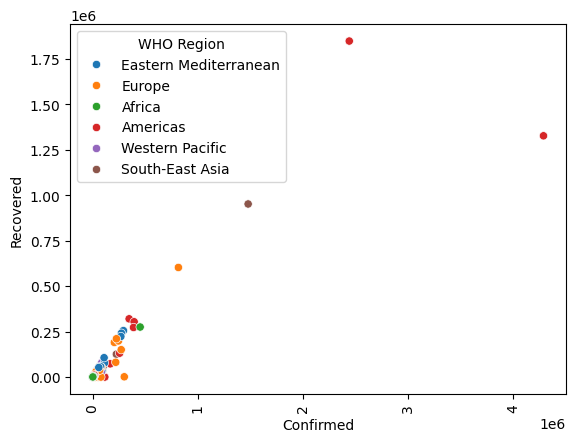

In [ ]:
sns.scatterplot(x='Confirmed', y= 'Recovered', data=df, hue='WHO Region')
plt.xticks(rotation=90)



<ipython-input-8-9bf2c112d952>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='Country/Region', data=df.sort_values(by='Confirmed', ascending=False).head(10), palette='viridis')


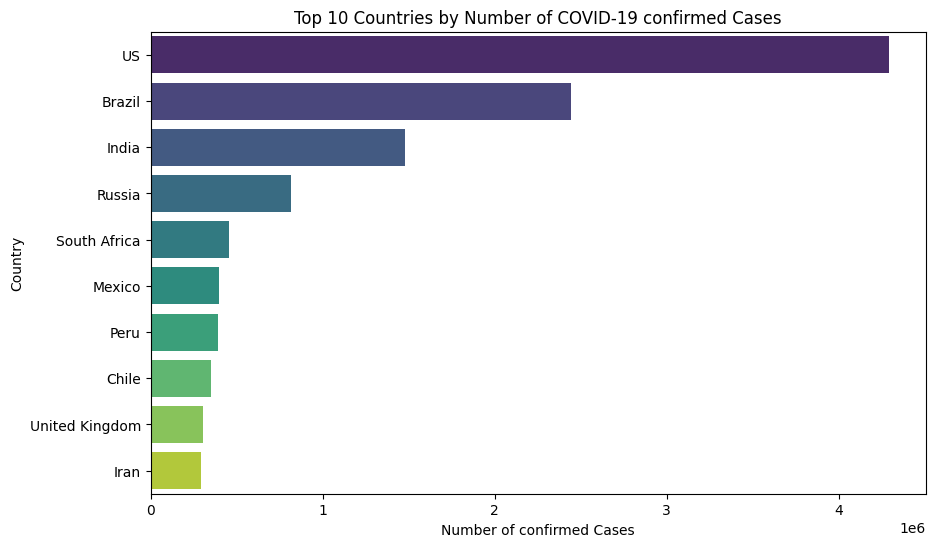

In [ ]:
df = df[['Country/Region', 'Confirmed']]
#לזכור להחזיר את הדאטה פריים למקור כקובץ סי אס וי

plt.figure(figsize=(10, 6))
sns.barplot(x='Confirmed', y='Country/Region', data=df.sort_values(by='Confirmed', ascending=False).head(10), palette='viridis')
plt.xlabel('Number of confirmed Cases')
plt.ylabel('Country')
plt.title('Top 10 Countries by Number of COVID-19 confirmed Cases')
plt.show()

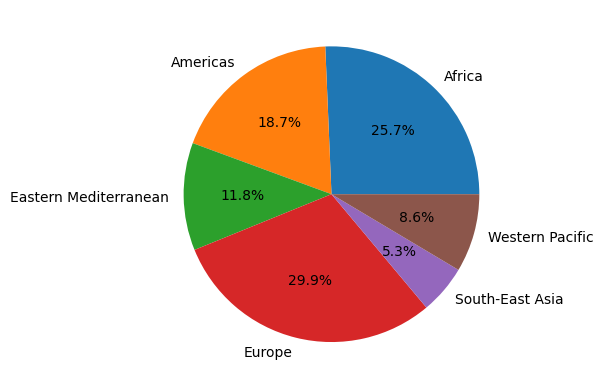

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/yehonatanm1/COVID/refs/heads/main/country_wise_latest.csv')
pp=df.groupby('WHO Region')['Deaths'].count()
plt.pie(pp,labels=pp.index,autopct='%1.1f%%')
plt.show()

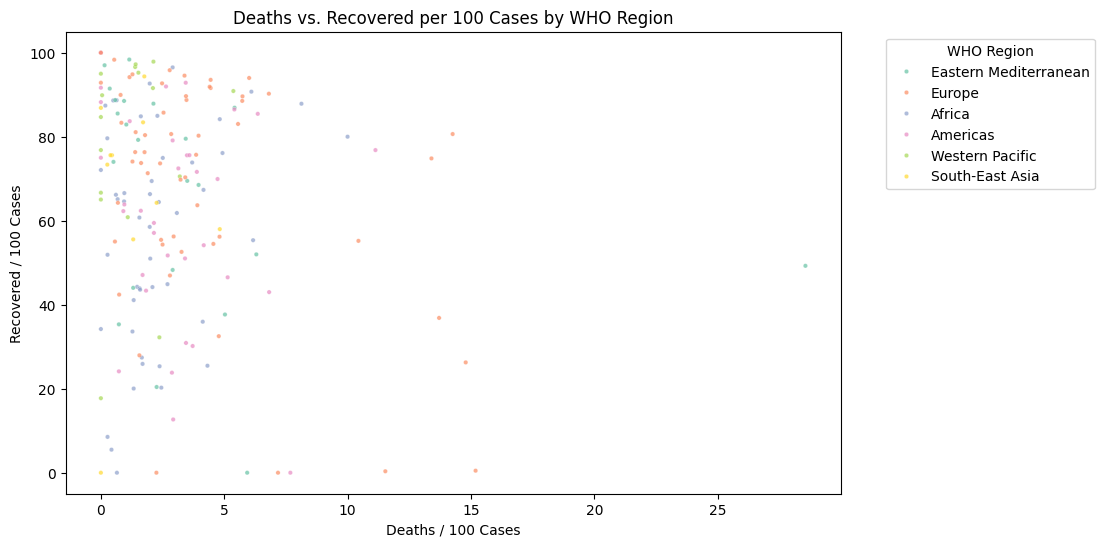

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Deaths / 100 Cases',
    y='Recovered / 100 Cases',
    hue='WHO Region',
    data=df,
    palette='Set2',
    s=10,
    edgecolor='w',
    alpha=0.7
)
plt.title('Deaths vs. Recovered per 100 Cases by WHO Region')
plt.xlabel('Deaths / 100 Cases')
plt.ylabel('Recovered / 100 Cases')
plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

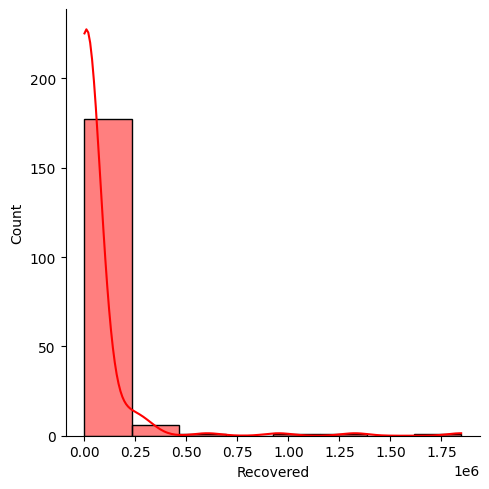

In [ ]:
sns.displot(df['Recovered'],kde=True,color='red',bins=8);

<ipython-input-12-e676eaccd7ea>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WHO Region',y='Confirmed',data=df, palette='rainbow')


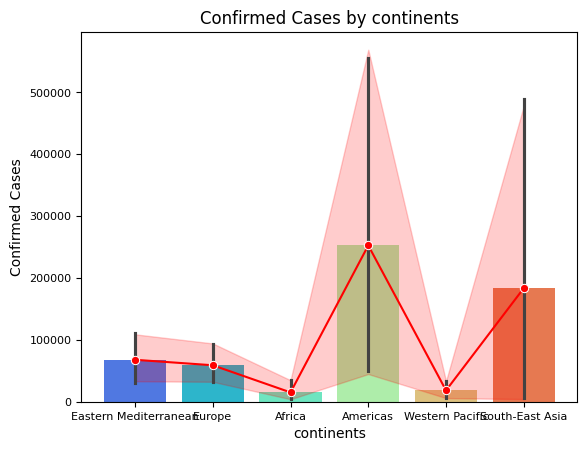

In [ ]:
sns.barplot(x='WHO Region',y='Confirmed',data=df, palette='rainbow')
sns.lineplot(x='WHO Region', y='Confirmed', data=df, marker='o', color='red')


plt.xlabel('continents')
plt.ylabel('Confirmed Cases')
plt.title('Confirmed Cases by continents')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.show()

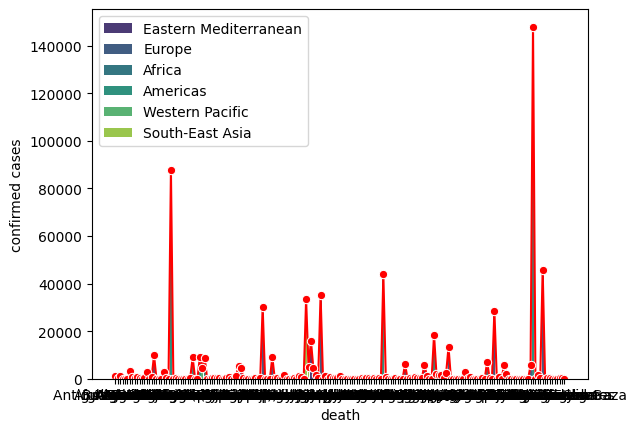

In [ ]:
sns.barplot(x='Country/Region', y='Deaths', data=df,hue='WHO Region', palette='viridis')
sns.lineplot(x='Country/Region', y='Deaths', data=df, marker='o', color='red')

plt.xlabel('death')
plt.ylabel('confirmed cases')

plt.show()

<ipython-input-14-f280a6d8d424>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deaths / 100 Cases',y='Recovered / 100 Cases',data=df, palette='rainbow')


<Axes: xlabel='Deaths / 100 Cases', ylabel='Recovered / 100 Cases'>

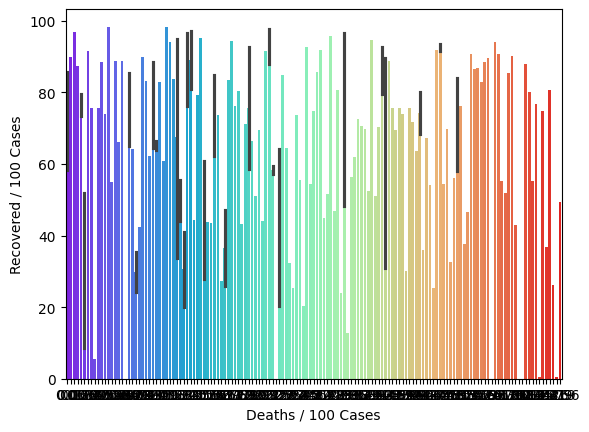

In [ ]:
sns.barplot(x='Deaths / 100 Cases',y='Recovered / 100 Cases',data=df, palette='rainbow')


<ipython-input-15-9bf2c112d952>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='Country/Region', data=df.sort_values(by='Confirmed', ascending=False).head(10), palette='viridis')


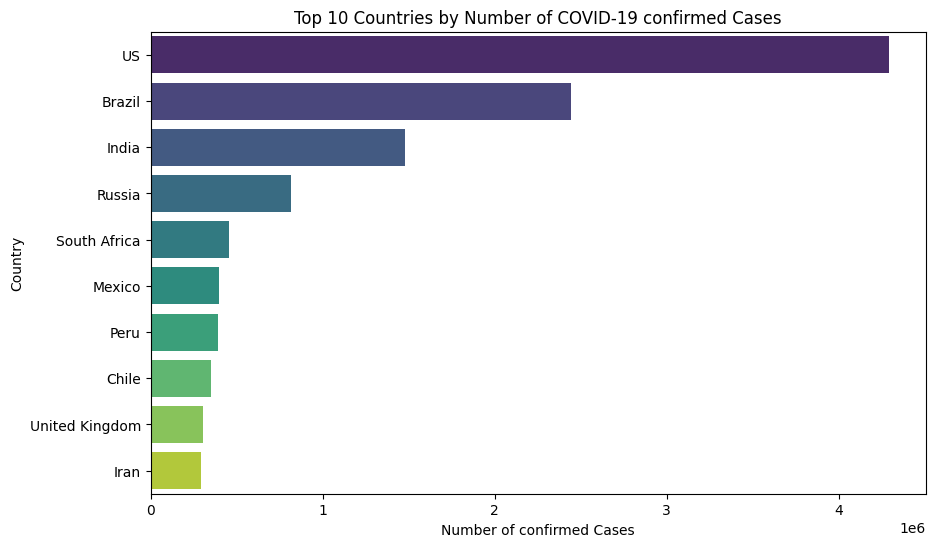

In [ ]:
df = df[['Country/Region', 'Confirmed']]
#לזכור להחזיר את הדאטה פריים למקור כקובץ סי אס וי

plt.figure(figsize=(10, 6))
sns.barplot(x='Confirmed', y='Country/Region', data=df.sort_values(by='Confirmed', ascending=False).head(10), palette='viridis')
plt.xlabel('Number of confirmed Cases')
plt.ylabel('Country')
plt.title('Top 10 Countries by Number of COVID-19 confirmed Cases')
plt.show()

<ipython-input-16-af014f186cbc>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='Country/Region', data=df.sort_values(by='Confirmed', ascending=False).head(10), palette='viridis')


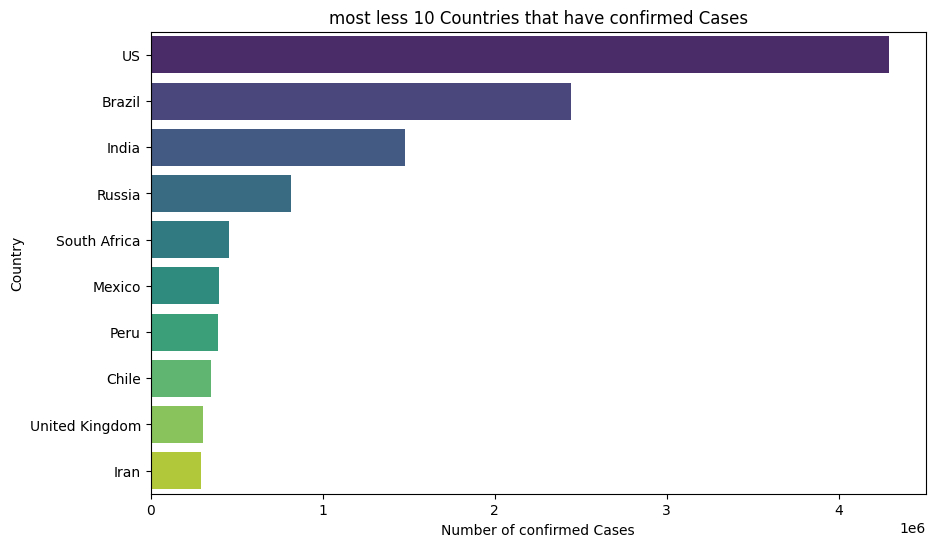

In [ ]:
df = df[['Country/Region', 'Confirmed']]
#לזכור להחזיר את הדאטה פריים למקור כקובץ סי אס וי

plt.figure(figsize=(10, 6))
sns.barplot(x='Confirmed', y='Country/Region', data=df.sort_values(by='Confirmed', ascending=False).head(10), palette='viridis')
plt.xlabel('Number of confirmed Cases')
plt.ylabel('Country')
plt.title('most less 10 Countries that have confirmed Cases')
plt.show()

In [ ]:
df

,Country/Region,Confirmed
0,Afghanistan,36263
1,Albania,4880
2,Algeria,27973
3,Andorra,907
4,Angola,950
...,...,...
182,West Bank and Gaza,10621
183,Western Sahara,10
184,Yemen,1691
185,Zambia,4552


In [ ]:
df



,Country/Region,Confirmed
0,Afghanistan,36263
1,Albania,4880
2,Algeria,27973
3,Andorra,907
4,Angola,950
...,...,...
182,West Bank and Gaza,10621
183,Western Sahara,10
184,Yemen,1691
185,Zambia,4552


## cleaned data

In [ ]:
df = df_backup
df.drop(['Recovered','Country/Region'],axis=1, inplace=True)


In [ ]:
df.drop('Confirmed',axis=1,inplace=False)

,Deaths,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,1269,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,144,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,1163,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,52,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,41,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...
182,78,6791,152,2,0,0.73,35.33,2.08,8916,1705,19.12,Eastern Mediterranean
183,1,1,0,0,0,10.00,80.00,12.50,10,0,0.00,Africa
184,483,375,10,4,36,28.56,49.26,57.98,1619,72,4.45,Eastern Mediterranean
185,140,1597,71,1,465,3.08,61.84,4.97,3326,1226,36.86,Africa


In [ ]:
df['Confirmed'].fillna(df['Confirmed'].mean(),inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Confirmed               187 non-null    int64  
 1   Deaths                  187 non-null    int64  
 2   Active                  187 non-null    int64  
 3   New cases               187 non-null    int64  
 4   New deaths              187 non-null    int64  
 5   New recovered           187 non-null    int64  
 6   Deaths / 100 Cases      187 non-null    float64
 7   Recovered / 100 Cases   187 non-null    float64
 8   Deaths / 100 Recovered  187 non-null    float64
 9   Confirmed last week     187 non-null    int64  
 10  1 week change           187 non-null    int64  
 11  1 week % increase       187 non-null    float64
 12  WHO Region              187 non-null    object 
dtypes: float64(4), int64(8), object(1)
memory usage: 19.1+ KB


<ipython-input-21-2e9de85e5978>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Confirmed'].fillna(df['Confirmed'].mean(),inplace=True)


In [ ]:
df['Active'].isnull().sum()#בודק אם יש נתונים חסרים תחת עמודה אקטיב

0

In [ ]:
null_rows=df[df['Active'].isnull()]# בשורה זו זה לא מראה דבר מכיוון שפעולה זאת מראה אך ורק  קוביות החסרות
null_rows.head()

,Confirmed,Deaths,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region


# Feature engineering

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/yehonatanm1/COVID/refs/heads/main/country_wise_latest.csv')
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [ ]:
#df['Country/Region'] = pd.to_numeric(df['Country/Region'], errors='coerce')
#df['WHO Region'] = pd.to_numeric(df['WHO Region'], errors='coerce')


In [ ]:
region_mapping = {'Europe': 1, 'Africa': 2, 'Americas': 3, 'Eastern Mediterranean' : 4, 'Western Pacific' : 5, 'South-East Asia' : 6 }
df['WHO Region'] = df['WHO Region'].map(region_mapping)
df.drop(['WHO Region','Country/Region'],axis=1, inplace=True)

In [ ]:
df.corr()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase
Confirmed,1.000000,0.934698,0.906377,0.927018,0.909720,0.871683,0.859252,0.063550,-0.064815,0.025175,0.999127,0.954710,-0.010161
Deaths,0.934698,1.000000,0.832098,0.871586,0.806975,0.814161,0.765114,0.251565,-0.114529,0.169006,0.939082,0.855330,-0.034708
Recovered,0.906377,0.832098,1.000000,0.682103,0.818942,0.820338,0.919203,0.048438,0.026610,-0.027277,0.899312,0.910013,-0.013697
Active,0.927018,0.871586,0.682103,1.000000,0.851190,0.781123,0.673887,0.054380,-0.132618,0.058386,0.931459,0.847642,-0.003752
New cases,0.909720,0.806975,0.818942,0.851190,1.000000,0.935947,0.914765,0.020104,-0.078666,-0.011637,0.896084,0.959993,0.030791
New deaths,0.871683,0.814161,0.820338,0.781123,0.935947,1.000000,0.889234,0.060399,-0.062792,-0.020750,0.862118,0.894915,0.025293
New recovered,0.859252,0.765114,0.919203,0.673887,0.914765,0.889234,1.000000,0.017090,-0.024293,-0.023340,0.839692,0.954321,0.032662
Deaths / 100 Cases,0.063550,0.251565,0.048438,0.054380,0.020104,0.060399,0.017090,1.000000,-0.168920,0.334594,0.069894,0.015095,-0.134534
Recovered / 100 Cases,-0.064815,-0.114529,0.026610,-0.132618,-0.078666,-0.062792,-0.024293,-0.168920,1.000000,-0.295381,-0.064600,-0.063013,-0.394254
Deaths / 100 Recovered,0.025175,0.169006,-0.027277,0.058386,-0.011637,-0.020750,-0.023340,0.334594,-0.295381,1.000000,0.030460,-0.013763,-0.049083


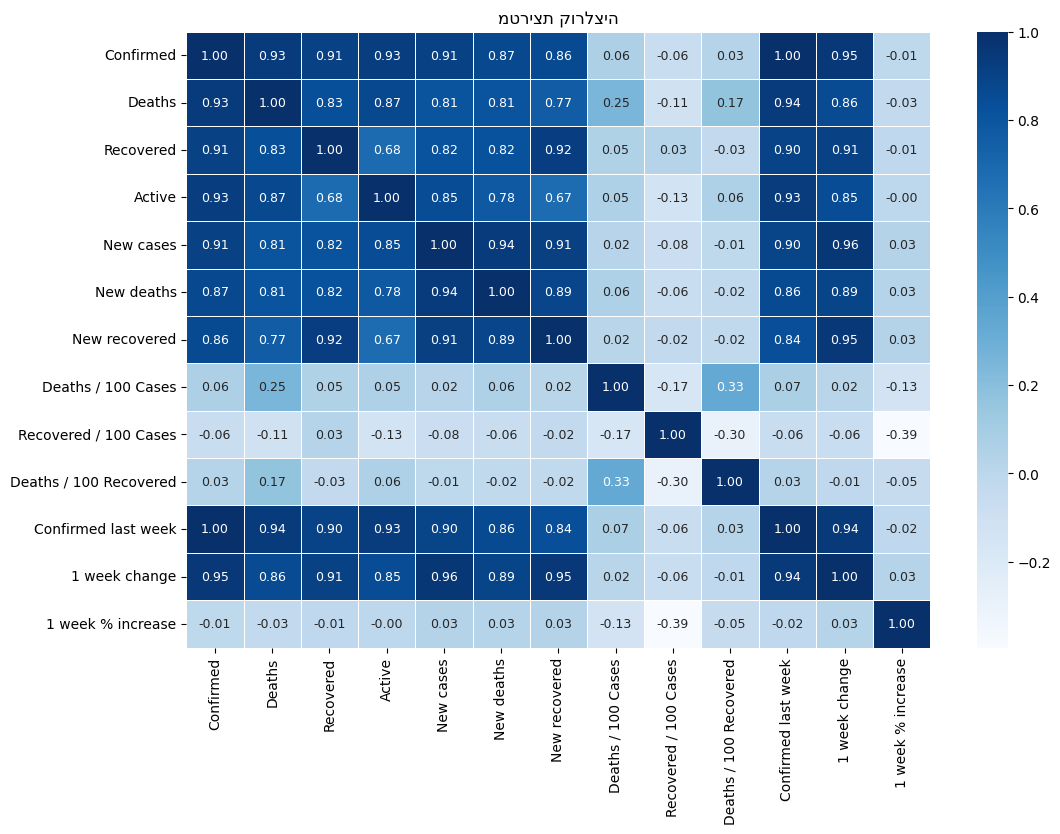

In [ ]:
plt.figure(figsize=(12, 8))
corr=df.corr()
sns.heatmap(corr,annot=True,cmap='Blues',fmt='.2f', linewidths=0.5,#aanot = true - מראה את המספרים בתוך הריבועים
            annot_kws={"size": 9})
plt.title('מטריצת קורלציה')
plt.show()

1: קשר חיובי חזק (כשהערך של משתנה אחד עולה, גם השני עולה).


-1: קשר שלילי חזק (כשהערך של משתנה אחד עולה, השני יורד).


0: אין קשר (המשתנים לא תלויים זה בזה).



לדוגמה:


קורלציה של 0.93 בין אומרת שיש קשר חזק בין מספר המאומתים למספר מקרי המוות.


קורלציה של -0.06 בין אומרת שהקשר חלש מאוד (כמעט אין תלות בין המשתנים).

ה

In [ ]:
df.corr()[['Deaths']]

,Deaths
Confirmed,0.934698
Deaths,1.000000
Recovered,0.832098
Active,0.871586
New cases,0.806975
New deaths,0.814161
New recovered,0.765114
Deaths / 100 Cases,0.251565
Recovered / 100 Cases,-0.114529
Deaths / 100 Recovered,0.169006


In [ ]:
df.corr()[['Deaths']].sort_values('Deaths', ascending=False).head(5)#מראה את חמשת העמודות בעלות היחסים הגבוהים ביותר ביחס מלמעלה למטה


,Deaths
Deaths,1.000000
Confirmed last week,0.939082
Confirmed,0.934698
Active,0.871586
1 week change,0.855330


# data test and prepare

המודל קובע 38 נקודות שהן בוחנות את הנתונים ומסווגת אותן לפי איזה סוג נקודות יש בקרבתן.



1 (High Survival Chance): אם יותר מ-50% מהחולים מתאוששים (Recovered / 100 Cases > 50).
0 (Low Survival Chance): אם פחות מ-50% מהחולים מתאוששים (Recovered / 100 Cases ≤ 50).

In [ ]:
file_path = "https://raw.githubusercontent.com/yehonatanm1/COVID/refs/heads/main/country_wise_latest.csv"
data = pd.read_csv(file_path)
print( data.head())

  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526            737   
1   

In [ ]:
X = data.select_dtypes(include=["number"]).drop(["Recovered / 100 Cases"], axis=1)#לוקח רק העמודות שמכילות מספרים
y = (data["Recovered / 100 Cases"] > 50).astype(int)  # העמודה שאותה נרצב לנבא (אנחנו נרצה לבדוק אם הסכיכויים גדולים מ50 אחוז)

In [ ]:
X = X.replace([float("inf"), float("-inf")], pd.NA).fillna(X.median())

<ipython-input-33-ce73c613dc23>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace([float("inf"), float("-inf")], pd.NA).fillna(X.median())


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train)#מנרמל את היחסים בין המרחקים בין נקודות בדיקה
X_test_scaled = scaler.transform(X_test)

# בניית המודל KNN
knn = KNeighborsClassifier(n_neighbors=5) #vהגדרת טווח בחירת נקודות
knn.fit(X_train_scaled, y_train)#אימון המודל

# חיזוי
y_pred = knn.predict(X_test_scaled)
print(y_pred)

# הערכת המודל
report = classification_report(y_test, y_pred, target_names=["Low Survival Chance", "High Survival Chance"])
print(report)

[0 1 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1
 1]
                      precision    recall  f1-score   support

 Low Survival Chance       0.89      0.57      0.70        14
High Survival Chance       0.79      0.96      0.87        24

            accuracy                           0.82        38
           macro avg       0.84      0.76      0.78        38
        weighted avg       0.83      0.82      0.80        38



המודל בודק מה דיוק החיזוי לגבי אם מדינה תיהיה בעלת סיכוי הישרדות גבוהה או נמוך, לדוגמא מהנתונים שנאחנו רואים בפלט אפשר להבין ש88 אחוז מהמדינות שסווגו כבעלות פחות מ50 אחוזי הישרדות המודל הצליח לזהות

הקוד מאמן את המודל על חלק מהנתונים ובודק את ביצועיו על חלק אחר שלא היה בשימוש בזמן האימון.

בודק את אחוזי התחזיות הנכונות שהוא ניבא מהתחזיות הנכונות בכללי - PRECISION
מתמקד ב-כמה המודל צודק מתוך מה שהוא ניבא.



Recall מתמקד בכמה מהנתונים בפועל המודל הצליח לזהות.





Accuracy (דיוק כללי): 0.79

המשמעות: 79% מכלל התחזיות של המודל היו נכונות (לשתי הקטגוריות יחד).
Macro Average (ממוצע מאוזן):

Precision: 0.82 - דיוק ממוצע לשתי הקטגוריות.
Recall: 0.74 - רגישות ממוצעת לשתי הקטגוריות.
F1-Score: 0.79 - ביצועים כלליים ממוצעים.

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


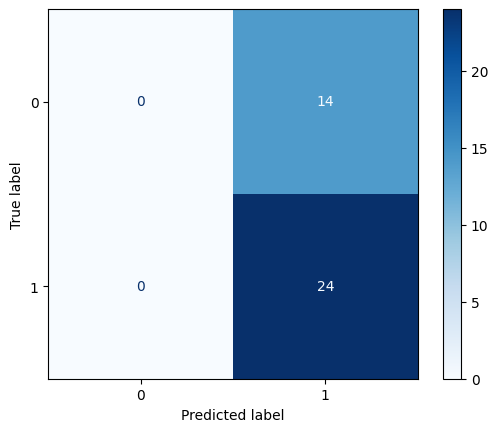

In [ ]:
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test,values_format="d",cmap='Blues');

המודל הא מודל רגרסיה לינארית זאת אמרת שהוא חוזה את אחוזי התמותה, המודל מנסה למצוא את הקו הישר (הקו הכי טוב) שמתאר את הקשר בין המשתנים.

רגרסיה לינארית מוצאת כמה נקודות בגרף שיש בהם קשר ישיר אחד לשני(מעין קו ישר) וחוזה מה תיהיה הנקודה הבאה לפי הנקודות הללו.


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
file_path = "https://raw.githubusercontent.com/yehonatanm1/COVID/refs/heads/main/country_wise_latest.csv"
data = pd.read_csv(file_path)
data['Survival Rate'] = (data['Recovered'] /  data['Confirmed']) * 100


X = data[['Deaths / 100 Cases', 'Recovered / 100 Cases']]  # נתונים על המקרים
y = data['Survival Rate']  # אחוזי הישרדות (אם יש לך עמודה כזו)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = LinearRegression()#קביעת הרגרסיה כלינארית (קו ישר)

regressor.fit(X_train, y_train)

# חיזוי על נתוני הבדיקה
y_pred = regressor.predict(X_test)
print(y_pred)
average_survival_rate = np.mean(y_pred)# פונקצייה מהאימפורט נאם פאי שמחשבת ממוצע
print(f"AveragePredicted Survival Rate: {average_survival_rate:.2f}%")


[ 6.18396898e+01  9.83295634e+01  7.20794494e+01  5.61898251e+01
 -1.13769216e-04  8.99495645e+01  9.99995210e+01  6.07495554e+01
  7.24597222e+01  5.54496180e+01  7.56094922e+01  6.61794871e+01
  8.33195501e+01  6.50394313e+01  4.29999653e+01  2.62706124e+01
  3.59497143e+01  4.80580956e-01  8.06407059e+01  8.68694873e+01
  4.41995589e+01  5.47931587e+00  7.55797605e+01  3.42093523e+01
  9.78696999e+01  8.30399589e+01  8.87497925e+01  7.37395948e+01
  7.03297410e+01  8.96199913e+01  5.85295861e+01  9.27097170e+01
  1.26795508e+01  8.86295351e+01  9.28595027e+01  9.19597289e+01
  2.53495356e+01  8.28995663e+01]
AveragePredicted Survival Rate: 64.18%


In [ ]:
df.nunique()

,0
Confirmed,184
Deaths,150
Recovered,178
Active,173
New cases,122
New deaths,38
New recovered,103
Deaths / 100 Cases,145
Recovered / 100 Cases,177
Deaths / 100 Recovered,155


In [ ]:
file_path = "https://raw.githubusercontent.com/yehonatanm1/COVID/refs/heads/main/country_wise_latest.csv"
data = pd.read_csv(file_path)

# בדיקת תקינות נתונים
data = data.dropna()  # מחיקת שורות עם ערכים חסרים

# הוספת עמודת 'Survival Rate'
data['Survival Rate'] = (  100 - (data['Deaths / 100 Cases'] ) )

# בחירת עמודות רלוונטיות
X = data[['Deaths / 100 Cases', 'Recovered / 100 Cases']]  # משתני קלט
y = data['Survival Rate']  # משתנה מטרה
y = y.replace([float("inf"), float("-inf")], pd.NA).fillna(y.median())
# חלוקה לנתוני אימון ובדיקה
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# יצירת מודל רגרסיה לינארית
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# חיזוי נתוני בדיקה
y_pred = regressor.predict(X_test)

# הדפסת תוצאות חיזוי
print("Predicted Survival Rates:")
print(y_pred)

# חישוב ממוצע אחוזי ההישרדות
average_survival_rate = np.mean(y_pred)
print(f"Average Predicted Survival Rate: {average_survival_rate:.2f}%")

# מדדי ביצועים

Predicted Survival Rates:
[ 96.92  99.46 100.    95.19  92.82  99.2  100.    98.44  96.86  97.56
  99.61  99.39  99.17 100.    93.18  85.21  95.87  84.81  85.74 100.
  97.91  99.57  96.51 100.    97.87  94.44  96.53  98.37  96.58  94.26
  98.02  97.52  97.07  99.5  100.    97.36  97.62  98.97]
Average Predicted Survival Rate: 96.78%


data['Survival Rate'] = (data['Recovered'] /  data['Confirmed']) * 100